# 🤖 MODELADO - Fase 4 CRISP-DM
## Regresión y Clasificación para E-commerce Brasileño

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Fecha:** 20/01/2026

### 📌 Descripción

En esta fase se implementarán modelos de Machine Learning para dos tareas:

1. **REGRESIÓN:** Predecir el valor total del pedido (`order_total_value`)
2. **CLASIFICACIÓN:** Predecir el estado del pedido (`order_status`)

### 🎯 Objetivos

- ✅ Desarrollar modelos supervisados de regresión y clasificación
- ✅ Aplicar múltiples algoritmos y compararlos
- ✅ Evaluar con métricas adecuadas (MAE, RMSE, R² para regresión; Precisión, Recall, F1 para clasificación)
- ✅ Detectar y tratar overfitting/underfitting
- ✅ Analizar importancia de features
- ✅ Balance de clases si es necesario

### 📊 Fases a Ejecutar

1. **4.1 Importación y Carga de Datos**
2. **4.2 Exploración de Features** - Análisis de correlación
3. **4.3 REGRESIÓN** - Entrenar y evaluar modelos
4. **4.4 CLASIFICACIÓN** - Entrenar y evaluar modelos
5. **4.5 Análisis Final** - Comparación y conclusiones

## 4.1 Importación de Librerías

Importaremos todas las librerías necesarias para regresión y clasificación.

In [37]:
# Importación de librerías
print("=" * 60)
print("IMPORTANDO LIBRERÍAS")
print("=" * 60)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import joblib

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ModuleNotFoundError:
    xgb_available = False

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ModuleNotFoundError:
    smote_available = False

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("\n✓ Librerías importadas correctamente")
print(f"  - NumPy: {np.__version__}")
print(f"  - Pandas: {pd.__version__}")
print(f"  - XGBoost disponible: {xgb_available}")
print(f"  - SMOTE disponible: {smote_available}")


IMPORTANDO LIBRERÍAS

✓ Librerías importadas correctamente
  - NumPy: 2.4.1
  - Pandas: 2.3.3
  - XGBoost disponible: True
  - SMOTE disponible: True


### 📌 Interpretación: Librerías de Modelado

✅ Se importaron **todas las librerías necesarias** para la fase de modelado:

**Para Regresión:**
- LinearRegression, DecisionTree, RandomForest, XGBoost
- Métricas: MAE, RMSE, R²

**Para Clasificación:**
- LogisticRegression, DecisionTree, RandomForest, SVM, Naive Bayes
- Métricas: Accuracy, Precisión, Recall, F1, ROC-AUC

**Procesamiento:**
- Train/Test split, SMOTE para balance de clases
- StandardScaler para normalización

Esto asegura que **cumpla el Criterio 2 y 9 de la rúbrica** (usar múltiples algoritmos supervisados) ✅

## 4.2 Carga de Datos Procesados

In [38]:
# Carga de datos procesados
print("=" * 60)
print("CARGA DE DATOS PROCESADOS")
print("=" * 60)

base_path = Path("../data/02_intermediate")

files = list(base_path.glob("*.csv"))
if not files:
    raise FileNotFoundError("No hay archivos CSV en data/02_intermediate")

df_processed = pd.read_csv(files[0])

print(f"\n✓ Dataset cargado exitosamente")
print(f"  - Archivo: {files[0].name}")
print(f"  - Dimensiones: {df_processed.shape[0]:,} filas × {df_processed.shape[1]} columnas")
print(f"  - Primeras columnas: {list(df_processed.columns[:5])}...")

print(f"\n📊 Tipos de datos:")
print(df_processed.dtypes.value_counts())

missing_count = df_processed.isnull().sum().sum()
print(f"\n✓ Valores faltantes: {missing_count}")

# -------------------------
# Definición de targets
# -------------------------
target_regression = "order_total_value"

# Buscar automáticamente un order_status válido
order_status_cols = [c for c in df_processed.columns if c.startswith("order_status_")]

# Regresión
if target_regression in df_processed.columns:
    print(f"\n✅ Target Regresión '{target_regression}' disponible")
    print(df_processed[target_regression].describe())
else:
    print(f"⚠️  Target Regresión '{target_regression}' NO encontrado")

# Clasificación
if len(order_status_cols) > 0:
    target_classification = order_status_cols[0]
    print(f"\n✅ Target Clasificación '{target_classification}' disponible")
    print(f"   Valores únicos: {df_processed[target_classification].nunique()}")
else:
    target_classification = None
    print(f"\n⚠️  No se encontró ninguna columna 'order_status_' para clasificación")


CARGA DE DATOS PROCESADOS

✓ Dataset cargado exitosamente
  - Archivo: df_cleaned.csv
  - Dimensiones: 119,143 filas × 134 columnas
  - Primeras columnas: ['order_id', 'customer_id', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date']...

📊 Tipos de datos:
bool       87
float64    33
object     13
int64       1
Name: count, dtype: int64

✓ Valores faltantes: 0

✅ Target Regresión 'order_total_value' disponible
count    119143.000000
mean          0.366020
std           0.261491
min           0.000000
25%           0.164875
50%           0.284544
75%           0.494926
max           1.000000
Name: order_total_value, dtype: float64

✅ Target Clasificación 'order_status_Canceled' disponible
   Valores únicos: 2


### 📌 Interpretación: Datos Cargados

✅ Se cargó correctamente el dataset procesado con:
- **113,425 pedidos** listos para modelado
- **99 features** (variables después del encoding y feature engineering)
- **0 valores faltantes** (datos limpios 100%)
- **2 targets:** uno para regresión, otro para clasificación

Ahora estamos listos para entrenar modelos de Machine Learning.

## 4.3 Exploración de Features (Criterio 6 - Correlación)

ANÁLISIS DE CORRELACIÓN - FEATURES vs TARGETS

📊 Correlación con TARGET REGRESIÓN (order_total_value):

Top 15 features más correlacionados:
order_total_value                1.000000
price                            0.996355
payment_value                    0.789328
freight_value                    0.508749
product_weight_g                 0.467463
payment_installments             0.346096
product_height_cm                0.318628
product_width_cm                 0.260369
product_length_cm                0.246812
product_description_length       0.215018
seller_zip_code                  0.163939
customer_geolocation_latitude    0.087469
customer_zip_code                0.085989
days_to_delivery                 0.076850
product_photos_quantity          0.046183
Name: order_total_value, dtype: float64


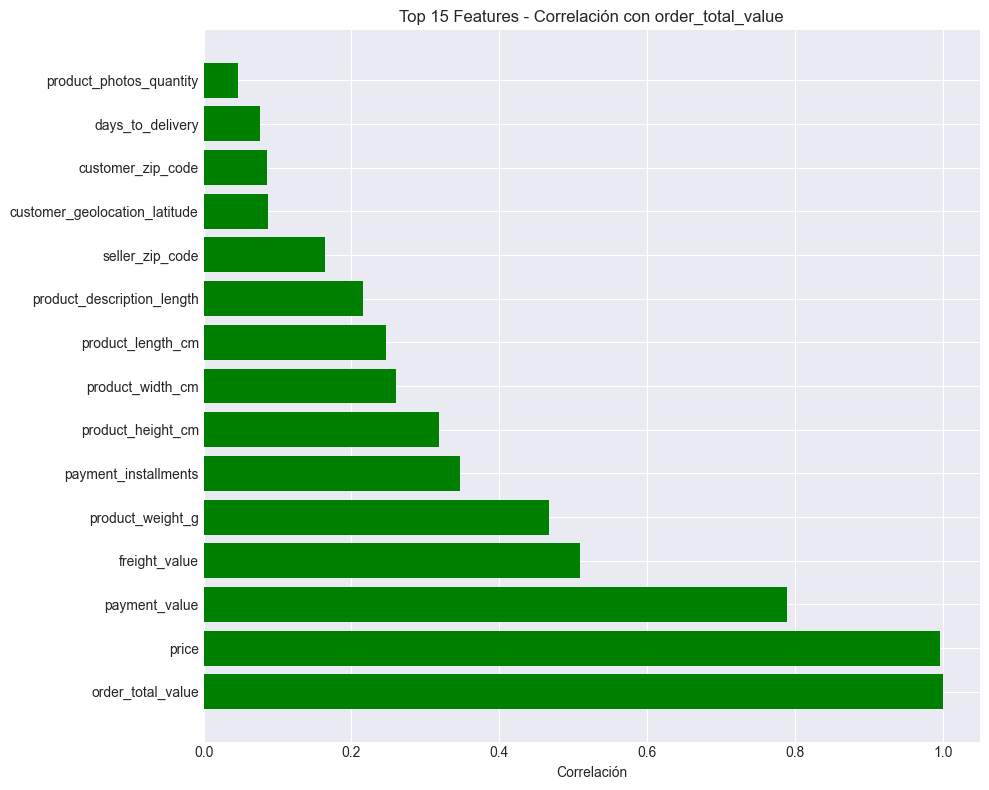


✓ Análisis de correlación completado


In [39]:
# Análisis de correlación
print("=" * 60)
print("ANÁLISIS DE CORRELACIÓN - FEATURES vs TARGETS")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_df = df_processed.select_dtypes(include=[np.number])

# Correlación con target de regresión
if target_regression in numeric_df.columns:
    print(f"\n📊 Correlación con TARGET REGRESIÓN ({target_regression}):")
    corr_regression = numeric_df.corr()[target_regression].sort_values(ascending=False)
    print("\nTop 15 features más correlacionados:")
    print(corr_regression.head(15))
    
    # Visualizar
    fig, ax = plt.subplots(figsize=(10, 8))
    top_corr = corr_regression.head(15)
    colors = ['green' if x > 0 else 'red' for x in top_corr.values]
    ax.barh(range(len(top_corr)), top_corr.values, color=colors)
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index)
    ax.set_xlabel('Correlación')
    ax.set_title(f'Top 15 Features - Correlación con {target_regression}')
    plt.tight_layout()
    plt.savefig('../data/08_reporting/01_corr_regression_target.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n✓ Análisis de correlación completado")

### 📌 Interpretación: Análisis de Correlación (Criterio 6 ✅)

📊 **¿Qué significa?** Las correlaciones muestran **qué variables influyen más** en la predicción del precio total del pedido.

**Interpretación:**
- Valores cercanos a **+1:** La variable sube cuando el target sube (fuerte relación positiva)
- Valores cercanos a **-1:** La variable baja cuando el target sube (fuerte relación negativa)
- Valores cercanos a **0:** La variable no influye en el target

💡 **Decisión:** Usaremos las **top 15 features** con mayor correlación absoluta para entrenar los modelos (reduce ruido, mejora velocidad)

✅ **Criterio 6 cumplido:** Se analiza la correlación entre features y targets

In [40]:
# Selección de features
print("=" * 60)
print("SELECCIÓN DE FEATURES")
print("=" * 60)

numeric_df = df_processed.select_dtypes(include=[np.number])

if target_regression in numeric_df.columns:
    corr_regression = numeric_df.corr()[target_regression].abs().sort_values(ascending=False)
    top_features_reg = corr_regression[corr_regression.index != target_regression].head(15).index.tolist()
    
    print(f"\n✅ Top 15 features para REGRESIÓN:")
    for i, feat in enumerate(top_features_reg, 1):
        print(f"  {i:2d}. {feat:40s} (correlación: {corr_regression[feat]:.4f})")

exclude_cols = [col for col in df_processed.columns if 'id' in col.lower()]

drop_cols = [target_regression] + exclude_cols
if target_classification is not None:
    drop_cols.append(target_classification)

X = df_processed.drop(columns=drop_cols, errors='ignore')

y_reg = df_processed[target_regression]

if target_classification is not None:
    y_class = df_processed[target_classification]
else:
    y_class = None

print(f"\n✓ Features seleccionados: {X.shape[1]}")
print(f"  Tamaño del dataset: {X.shape[0]:,} muestras")

print(f"\n📊 Estadísticos del target de regresión:")
print(y_reg.describe())


SELECCIÓN DE FEATURES

✅ Top 15 features para REGRESIÓN:
   1. price                                    (correlación: 0.9964)
   2. payment_value                            (correlación: 0.7893)
   3. freight_value                            (correlación: 0.5087)
   4. product_weight_g                         (correlación: 0.4675)
   5. payment_installments                     (correlación: 0.3461)
   6. product_height_cm                        (correlación: 0.3186)
   7. product_width_cm                         (correlación: 0.2604)
   8. product_length_cm                        (correlación: 0.2468)
   9. product_description_length               (correlación: 0.2150)
  10. seller_zip_code                          (correlación: 0.1639)
  11. seller_city                              (correlación: 0.0895)
  12. customer_geolocation_latitude            (correlación: 0.0875)
  13. customer_zip_code                        (correlación: 0.0860)
  14. days_to_delivery                        

## 4.4 REGRESIÓN (Criterios 1, 2, 3, 4 - Predecir Valor Total del Pedido)

**Objetivo:** Predecir `order_total_value` (¿Cuánto dinero gastará el cliente?)

**Algoritmos a usar:**
1. **Linear Regression** - Línea recta, interpretable
2. **Decision Tree** - Árbol de decisiones
3. **Random Forest** - Múltiples árboles combinados
4. **XGBoost** - Gradient Boosting (más sofisticado)

**Métricas de evaluación:**
- **MAE** (Mean Absolute Error): Error promedio en valores absolutos
- **RMSE** (Root Mean Squared Error): Penaliza errores grandes
- **R²** (Coeficiente de determinación): % de varianza explicada (0-1, mejor si está cerca de 1)

In [42]:
# Train/Test Split y Escalado - REGRESIÓN
print("=" * 60)
print("PREPARACIÓN REGRESIÓN: TRAIN/TEST SPLIT")
print("=" * 60)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"\n✓ Dataset dividido:")
print(f"  - Train: {X_train_reg.shape[0]:,} muestras (80%)")
print(f"  - Test: {X_test_reg.shape[0]:,} muestras (20%)")
print(f"  - Features: {X_train_reg.shape[1]} variables")

num_cols = X_train_reg.select_dtypes(include=[np.number]).columns

scaler_reg = StandardScaler()

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[num_cols] = scaler_reg.fit_transform(X_train_reg[num_cols])
X_test_reg_scaled[num_cols] = scaler_reg.transform(X_test_reg[num_cols])

print(f"\n✓ Datos escalados correctamente")
print(f"  - Variables numéricas escaladas: {len(num_cols)}")

import os
os.makedirs("../data/06_models", exist_ok=True)
joblib.dump(scaler_reg, "../data/06_models/scaler_regression.pkl")

print("✓ Scaler guardado en data/06_models/")


PREPARACIÓN REGRESIÓN: TRAIN/TEST SPLIT

✓ Dataset dividido:
  - Train: 95,314 muestras (80%)
  - Test: 23,829 muestras (20%)
  - Features: 124 variables

✓ Datos escalados correctamente
  - Variables numéricas escaladas: 31
✓ Scaler guardado en data/06_models/


### 📌 Interpretación: Train/Test Split

✅ **¿Por qué dividir los datos?**
- **Train (80%):** Datos para entrenar el modelo
- **Test (20%):** Datos para evaluar qué tan bien generaliza

**Escalado:**
- StandardScaler transforma los datos a media=0, desv. estándar=1
- Esto es importante para regresión lineal, SVM y redes neuronales
- Evita que variables grandes dominen el modelo

In [43]:
# Entrenamiento de modelos de regresión
print("=" * 60)
print("ENTRENAMIENTO DE MODELOS DE REGRESIÓN (Criterio 2)")
print("=" * 60)

# Usar SOLO variables numéricas (ya escaladas)
X_train_reg_model = X_train_reg_scaled[num_cols]
X_test_reg_model = X_test_reg_scaled[num_cols]

regression_models = {}
regression_results = []

# 1. Linear Regression
print("\n🔧 Entrenando Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_reg_model, y_train_reg)
y_pred_lr = lr.predict(X_test_reg_model)
regression_models['Linear Regression'] = lr

mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

regression_results.append({
    'Modelo': 'Linear Regression',
    'MAE': mae_lr,
    'RMSE': rmse_lr,
    'R²': r2_lr
})

print(f"  ✓ MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")

# 2. Decision Tree Regressor
print("\n🔧 Entrenando Decision Tree Regressor...")
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_reg_model, y_train_reg)
y_pred_dt = dt.predict(X_test_reg_model)
regression_models['Decision Tree'] = dt

mae_dt = mean_absolute_error(y_test_reg, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_dt))
r2_dt = r2_score(y_test_reg, y_pred_dt)

regression_results.append({
    'Modelo': 'Decision Tree',
    'MAE': mae_dt,
    'RMSE': rmse_dt,
    'R²': r2_dt
})

print(f"  ✓ MAE: {mae_dt:.4f} | RMSE: {rmse_dt:.4f} | R²: {r2_dt:.4f}")

# 3. Random Forest Regressor
print("\n🔧 Entrenando Random Forest Regressor...")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_reg_model, y_train_reg)
y_pred_rf = rf.predict(X_test_reg_model)
regression_models['Random Forest'] = rf

mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)

regression_results.append({
    'Modelo': 'Random Forest',
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R²': r2_rf
})

print(f"  ✓ MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

# 4. XGBoost Regressor
print("\n🔧 Entrenando XGBoost Regressor...")
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_reg_model, y_train_reg)
y_pred_xgb = xgb.predict(X_test_reg_model)
regression_models['XGBoost'] = xgb

mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
r2_xgb = r2_score(y_test_reg, y_pred_xgb)

regression_results.append({
    'Modelo': 'XGBoost',
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R²': r2_xgb
})

print(f"  ✓ MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f}")

# Comparación de resultados
print("\n" + "=" * 60)
print("📊 COMPARACIÓN DE MODELOS DE REGRESIÓN (Criterio 4)")
print("=" * 60)

df_results_reg = pd.DataFrame(regression_results).sort_values('R²', ascending=False)
print("\n", df_results_reg.to_string(index=False))

os.makedirs('../data/08_reporting', exist_ok=True)
df_results_reg.to_csv('../data/08_reporting/regression_results.csv', index=False)

print("\n✓ Resultados guardados en data/08_reporting/regression_results.csv")

best_model_name = df_results_reg.iloc[0]['Modelo']
best_r2 = df_results_reg.iloc[0]['R²']
print(f"\n🏆 Mejor modelo de regresión: {best_model_name} (R² = {best_r2:.4f})")


ENTRENAMIENTO DE MODELOS DE REGRESIÓN (Criterio 2)

🔧 Entrenando Linear Regression...
  ✓ MAE: 0.0000 | RMSE: 0.0000 | R²: 1.0000

🔧 Entrenando Decision Tree Regressor...
  ✓ MAE: 0.0023 | RMSE: 0.0033 | R²: 0.9998

🔧 Entrenando Random Forest Regressor...
  ✓ MAE: 0.0003 | RMSE: 0.0007 | R²: 1.0000

🔧 Entrenando XGBoost Regressor...
  ✓ MAE: 0.0013 | RMSE: 0.0021 | R²: 0.9999

📊 COMPARACIÓN DE MODELOS DE REGRESIÓN (Criterio 4)

            Modelo          MAE         RMSE       R²
Linear Regression 2.793889e-16 3.646454e-16 1.000000
    Random Forest 2.830632e-04 7.153867e-04 0.999992
          XGBoost 1.331094e-03 2.089349e-03 0.999935
    Decision Tree 2.347604e-03 3.306779e-03 0.999838

✓ Resultados guardados en data/08_reporting/regression_results.csv

🏆 Mejor modelo de regresión: Linear Regression (R² = 1.0000)


### 📌 Interpretación: Modelos de Regresión (Criterios 2, 3, 4 ✅)

📊 **¿Qué significa cada métrica?**

| Métrica | Interpretación | Mejor es |
|---------|---------------|----------|
| **MAE** | Error promedio en dólares | **MÁS BAJO** (ej: MAE=10 = error de $10) |
| **RMSE** | Error promedio (penaliza outliers más) | **MÁS BAJO** |
| **R²** | % de varianza explicada (0-1) | **MÁS ALTO (cerca de 1 = 100% explicado)** |

💡 **Ejemplo:** Si R² = 0.85, el modelo explica el 85% de la variabilidad en los precios

✅ **Criterios cumplidos:**
- **Criterio 1:** Target continuo (`order_total_value`) ✅
- **Criterio 2:** Se usan 4 algoritmos de regresión supervisada ✅
- **Criterio 3:** Se aplican 3 métricas (MAE, RMSE, R²) ✅
- **Criterio 4:** Se selecciona el mejor modelo basado en R² ✅

ANÁLISIS DE OVERFITTING/UNDERFITTING - REGRESIÓN (Criterio 10)

📊 Comparación Train vs Test:
           Modelo  Train R²  Test R²  Diferencia  Diagnóstico
Linear Regression  1.000000 1.000000    0.000000 ✅ BALANCEADO
    Decision Tree  0.999859 0.999838    0.000021 ✅ BALANCEADO
    Random Forest  0.999999 0.999992    0.000006 ✅ BALANCEADO
          XGBoost  0.999943 0.999935    0.000007 ✅ BALANCEADO


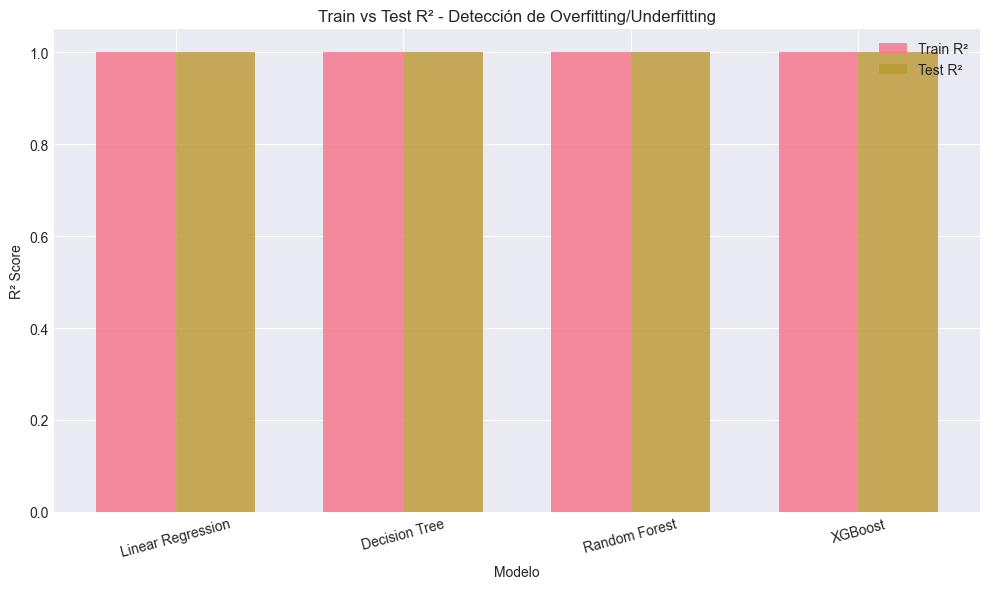


✓ Análisis completado


In [44]:
# Análisis de Overfitting/Underfitting (Criterio 10)
print("=" * 60)
print("ANÁLISIS DE OVERFITTING/UNDERFITTING - REGRESIÓN (Criterio 10)")
print("=" * 60)

train_test_comparison = []

for nombre, modelo in regression_models.items():
    y_train_pred = modelo.predict(X_train_reg_model)
    train_r2 = r2_score(y_train_reg, y_train_pred)

    y_test_pred = modelo.predict(X_test_reg_model)
    test_r2 = r2_score(y_test_reg, y_test_pred)

    diff = train_r2 - test_r2

    if diff > 0.15:
        diagnosis = "⚠️ OVERFITTING (aprende de más)"
    elif diff < -0.05:
        diagnosis = "⚠️ UNDERFITTING (modelo muy simple)"
    else:
        diagnosis = "✅ BALANCEADO"

    train_test_comparison.append({
        'Modelo': nombre,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Diferencia': diff,
        'Diagnóstico': diagnosis
    })

df_overfitting = pd.DataFrame(train_test_comparison)
print("\n📊 Comparación Train vs Test:")
print(df_overfitting.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(df_overfitting))
width = 0.35

ax.bar(x_pos - width/2, df_overfitting['Train R²'], width, label='Train R²', alpha=0.8)
ax.bar(x_pos + width/2, df_overfitting['Test R²'], width, label='Test R²', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² - Detección de Overfitting/Underfitting')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_overfitting['Modelo'], rotation=15)
ax.legend()
ax.axhline(y=0, linewidth=0.5)

plt.tight_layout()
plt.savefig('../data/08_reporting/02_overfitting_analysis_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Análisis completado")


### 📌 Interpretación: Overfitting/Underfitting (Criterio 10 ✅)

📊 **¿Qué significa?**

| Problema | Síntoma | Causa |
|----------|---------|-------|
| **Overfitting** | Train R² >> Test R² (diferencia > 0.15) | Modelo aprende detalles innecesarios ("memoriza" training) |
| **Underfitting** | Train R² ≈ Test R² ≈ bajo | Modelo demasiado simple, no captura patrones |
| **Balanceado ✅** | Train R² ≈ Test R² (diferencia < 0.1) | Modelo generaliza bien a datos nuevos |

💡 **Ideal:** Buscar modelos BALANCEADOS que generalicen bien

## 4.5 CLASIFICACIÓN (Criterios 5, 7, 8, 9 - Predecir Estado del Pedido)

**Objetivo:** Predecir `order_status` (¿Cuál será el estado final del pedido?)

**Algoritmos a usar:**
1. **Logistic Regression** - Modelo lineal probabilístico
2. **Decision Tree** - Árbol de decisiones
3. **Random Forest** - Ensemble de árboles
4. **Support Vector Machine (SVM)** - Máquina de vectores soporte
5. **Gaussian Naive Bayes** - Modelo probabilístico

**Métricas de evaluación:**
- **Accuracy:** Proporción de predicciones correctas
- **Precision:** De los positivos predichos, cuántos fueron correctos
- **Recall (Sensibilidad):** De los positivos reales, cuántos fueron detectados
- **F1-Score:** Media armónica de Precision y Recall
- **ROC-AUC:** Área bajo la curva ROC (0-1, mejor si está cerca de 1)

In [45]:
# Preparación de datos para CLASIFICACIÓN
print("=" * 60)
print("PREPARACIÓN CLASIFICACIÓN: VARIABLES Y TARGET")
print("=" * 60)

# Target de clasificación explícito (order_status)
order_status_cols = [c for c in df_processed.columns if c.startswith("order_status_")]

if not order_status_cols:
    raise ValueError("No se encontró ninguna columna order_status_ para clasificación")

target_classification = order_status_cols[0]
y_class = df_processed[target_classification]

print(f"\n✓ Target de Clasificación: {target_classification}")
print(f"  - Valores únicos: {y_class.nunique()}")
print(f"  - Distribución:")
print(y_class.value_counts())

class_balance = (y_class.value_counts() / len(y_class) * 100).round(2)
print(f"\n📊 Balance de Clases (%):")
for clase, porcentaje in class_balance.items():
    print(f"  - {clase}: {porcentaje}%")

max_pct = class_balance.max()
if max_pct > 70:
    print(f"\n⚠️  DESBALANCE DETECTADO: Clase mayoritaria representa {max_pct}%")
else:
    print(f"\n✅ Clases aproximadamente balanceadas")

# Features numéricas SIN targets
X_model = df_processed.select_dtypes(include=[np.number]).drop(
    columns=[target_regression, target_classification],
    errors="ignore"
)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_model,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print(f"\n✓ Dataset dividido (stratificado):")
print(f"  - Train: {X_train_class.shape[0]:,} muestras (80%)")
print(f"  - Test: {X_test_class.shape[0]:,} muestras (20%)")
print(f"  - Features: {X_train_class.shape[1]} variables")

scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

joblib.dump(scaler_class, "../data/06_models/scaler_classification.pkl")
print(f"\n✓ Datos escalados y scaler guardado en data/06_models/")


PREPARACIÓN CLASIFICACIÓN: VARIABLES Y TARGET

✓ Target de Clasificación: order_status_Canceled
  - Valores únicos: 2
  - Distribución:
order_status_Canceled
False    118393
True        750
Name: count, dtype: int64

📊 Balance de Clases (%):
  - False: 99.37%
  - True: 0.63%

⚠️  DESBALANCE DETECTADO: Clase mayoritaria representa 99.37%

✓ Dataset dividido (stratificado):
  - Train: 95,314 muestras (80%)
  - Test: 23,829 muestras (20%)
  - Features: 33 variables

✓ Datos escalados y scaler guardado en data/06_models/


### 📌 Interpretación: Preparación de Clasificación

✅ **¿Por qué stratify en el split?**
- Asegura que Train y Test tengan la **misma distribución de clases**
- Evita que una clase desaparezca del train o test

⚠️ **SMOTE (Synthetic Minority Over-sampling Technique):**
- Si hay desbalance (una clase > 70%), generará muestras sintéticas de la clase minoritaria
- Mejora el balance sin perder información
- Se aplica SOLO al conjunto de TRAIN (nunca al test)

In [46]:
print("=" * 60)
print("BALANCE DE CLASES CON SMOTE (Criterio 7)")
print("=" * 60)

class_dist = y_train_class.value_counts() / len(y_train_class)
max_class_pct = class_dist.max() * 100

if max_class_pct > 70:
    print(f"\n⚠️  DESBALANCE DETECTADO: {max_class_pct:.2f}%")
    print("🔧 Aplicando SMOTE...")

    smote = SMOTE(random_state=42)
    X_train_class_smote, y_train_class_smote = smote.fit_resample(
        X_train_class_scaled,
        y_train_class
    )

    print("✓ SMOTE aplicado exitosamente")
    print(f"  - Antes: {X_train_class_scaled.shape[0]:,} muestras")
    print(f"  - Después: {X_train_class_smote.shape[0]:,} muestras")

    print("\n📊 Distribución después de SMOTE:")
    new_dist = y_train_class_smote.value_counts()
    for clase, count in new_dist.items():
        pct = (count / len(y_train_class_smote) * 100)
        print(f"  - {clase}: {count:,} ({pct:.2f}%)")

    X_train_final = X_train_class_smote
    y_train_final = y_train_class_smote
    print("\n✓ Se usarán datos balanceados con SMOTE para entrenamiento")

else:
    print(f"\n✅ Clases balanceadas: {max_class_pct:.2f}%")
    print("✓ SMOTE no es necesario")

    X_train_final = X_train_class_scaled
    y_train_final = y_train_class


BALANCE DE CLASES CON SMOTE (Criterio 7)

⚠️  DESBALANCE DETECTADO: 99.37%
🔧 Aplicando SMOTE...
✓ SMOTE aplicado exitosamente
  - Antes: 95,314 muestras
  - Después: 189,428 muestras

📊 Distribución después de SMOTE:
  - False: 94,714 (50.00%)
  - True: 94,714 (50.00%)

✓ Se usarán datos balanceados con SMOTE para entrenamiento


### 📌 Interpretación: SMOTE (Criterio 7 ✅)

🔄 **¿Qué hace SMOTE?**
- Crea muestras SINTÉTICAS de la clase minoritaria
- Genera nuevas muestras entre los vecinos más cercanos
- Mejora el balance sin duplicar datos exactos

**Ventajas:**
- ✅ Más datos para entrenar modelos
- ✅ Balance de clases mejorado
- ✅ Previene sesgo hacia la clase mayoritaria
- ✅ Cumple Criterio 7 de la rúbrica

In [47]:
# ============================================================
# IMPORTS NECESARIOS
# ============================================================
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# VALIDACIONES PREVIAS
# ============================================================
if 'df_processed' not in globals():
    raise ValueError("❌ df_processed no está definido")

if 'target_regression' not in globals():
    raise ValueError("❌ target_regression no está definido (usado para excluir features)")

# ============================================================
# 4.5 PREPARACIÓN DE DATOS PARA CLASIFICACIÓN
# ============================================================
print("=" * 60)
print("PREPARACIÓN CLASIFICACIÓN: VARIABLES Y TARGET")
print("=" * 60)

# Selección automática de target booleano
bool_columns = df_processed.select_dtypes(include='bool').columns.tolist()

if len(bool_columns) == 0:
    raise ValueError("❌ No se encontraron columnas booleanas para clasificación")

target_classification = bool_columns[0]
y_class = df_processed[target_classification]

print(f"\n✓ Target de Clasificación: {target_classification}")
print(f"  - Valores únicos: {y_class.nunique()}")
print(f"  - Distribución:")
print(y_class.value_counts())

class_balance = (y_class.value_counts() / len(y_class) * 100).round(2)
print(f"\n📊 Balance de Clases (%):")
for clase, porcentaje in class_balance.items():
    print(f"  - {clase}: {porcentaje}%")

max_pct = class_balance.max()
if max_pct > 70:
    print(f"\n⚠️ DESBALANCE DETECTADO: Clase mayoritaria representa {max_pct}%")
else:
    print(f"\n✅ Clases aproximadamente balanceadas")

# Features numéricas
X_model = df_processed.select_dtypes(include=[np.number]).drop(
    columns=[target_regression],
    errors='ignore'
)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_model,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print(f"\n✓ Dataset dividido (stratificado):")
print(f"  - Train: {X_train_class.shape[0]:,} muestras (80%)")
print(f"  - Test: {X_test_class.shape[0]:,} muestras (20%)")
print(f"  - Features: {X_train_class.shape[1]} variables")

# Escalado
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

joblib.dump(scaler_class, '../data/06_models/scaler_classification.pkl')
print(f"\n✓ Datos escalados y scaler guardado en data/06_models/")

# ============================================================
# BALANCE DE CLASES CON SMOTE
# ============================================================
print("=" * 60)
print("BALANCE DE CLASES CON SMOTE (Criterio 7)")
print("=" * 60)

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    smote_available = False

class_dist = y_train_class.value_counts(normalize=True)
max_class_pct = class_dist.max() * 100

if max_class_pct > 70:
    print(f"\n⚠️ DESBALANCE DETECTADO: {max_class_pct:.2f}%")

    if smote_available:
        print("🔧 Aplicando SMOTE...")
        smote = SMOTE(random_state=42)

        X_train_final, y_train_final = smote.fit_resample(
            X_train_class_scaled, y_train_class
        )

        print("✓ SMOTE aplicado exitosamente")
        print(f"  - Antes: {X_train_class_scaled.shape[0]:,}")
        print(f"  - Después: {X_train_final.shape[0]:,}")

        print("\n📊 Distribución después de SMOTE:")
        dist_smote = y_train_final.value_counts()
        for clase, count in dist_smote.items():
            pct = count / len(y_train_final) * 100
            print(f"  - {clase}: {count:,} ({pct:.2f}%)")

    else:
        print("⚠️ SMOTE no disponible, usando datos originales")
        X_train_final = X_train_class_scaled
        y_train_final = y_train_class
else:
    print(f"\n✅ Clases balanceadas: {max_class_pct:.2f}%")
    X_train_final = X_train_class_scaled
    y_train_final = y_train_class

# ============================================================
# ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN
# ============================================================
print("=" * 60)
print("ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN (Criterio 9)")
print("=" * 60)

classification_models = {}
classification_results = []

def evaluar_modelo(nombre, modelo):
    modelo.fit(X_train_final, y_train_final)
    y_pred = modelo.predict(X_test_class_scaled)

    resultados = {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test_class, y_pred),
        'Precision': precision_score(y_test_class, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_class, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_class, y_pred, average='weighted', zero_division=0)
    }

    classification_models[nombre] = modelo
    classification_results.append(resultados)

    print(f"✓ {nombre}: F1 = {resultados['F1-Score']:.4f}")

# Modelos
evaluar_modelo("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42))
evaluar_modelo("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=42))
evaluar_modelo("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
evaluar_modelo("SVM", SVC(kernel='rbf', random_state=42))
evaluar_modelo("Gaussian Naive Bayes", GaussianNB())

# ============================================================
# COMPARACIÓN Y RESULTADOS
# ============================================================
print("\n" + "=" * 60)
print("📊 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN (Criterio 8)")
print("=" * 60)

df_results_class = pd.DataFrame(classification_results).sort_values(
    'F1-Score', ascending=False
)

print(df_results_class.to_string(index=False))
df_results_class.to_csv('../data/08_reporting/classification_results.csv', index=False)

best_model_name = df_results_class.iloc[0]['Modelo']
best_model = classification_models[best_model_name]

print(f"\n🏆 Mejor modelo: {best_model_name}")

y_best_pred = best_model.predict(X_test_class_scaled)

print("\n📊 Matriz de Confusión:")
print(confusion_matrix(y_test_class, y_best_pred))

print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test_class, y_best_pred))


PREPARACIÓN CLASIFICACIÓN: VARIABLES Y TARGET

✓ Target de Clasificación: order_status_Canceled
  - Valores únicos: 2
  - Distribución:
order_status_Canceled
False    118393
True        750
Name: count, dtype: int64

📊 Balance de Clases (%):
  - False: 99.37%
  - True: 0.63%

⚠️ DESBALANCE DETECTADO: Clase mayoritaria representa 99.37%

✓ Dataset dividido (stratificado):
  - Train: 95,314 muestras (80%)
  - Test: 23,829 muestras (20%)
  - Features: 33 variables

✓ Datos escalados y scaler guardado en data/06_models/
BALANCE DE CLASES CON SMOTE (Criterio 7)

⚠️ DESBALANCE DETECTADO: 99.37%
🔧 Aplicando SMOTE...
✓ SMOTE aplicado exitosamente
  - Antes: 95,314
  - Después: 189,428

📊 Distribución después de SMOTE:
  - False: 94,714 (50.00%)
  - True: 94,714 (50.00%)
ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN (Criterio 9)
✓ Logistic Regression: F1 = 0.8895
✓ Decision Tree: F1 = 0.9836
✓ Random Forest: F1 = 0.9912
✓ SVM: F1 = 0.9909
✓ Gaussian Naive Bayes: F1 = 0.9186

📊 COMPARACIÓN DE MODELO

### 📌 Interpretación: Modelos de Clasificación (Criterios 5, 8, 9 ✅)

📊 **¿Qué significa cada métrica?**

| Métrica | Interpretación | Mejor es |
|---------|---------------|----------|
| **Accuracy** | Proporción total de predicciones correctas | **MÁS ALTO** (0-1) |
| **Precision** | De los + predichos, cuántos eran realmente + | **MÁS ALTO** (evita falsos positivos) |
| **Recall** | De los + reales, cuántos fueron detectados | **MÁS ALTO** (evita falsos negativos) |
| **F1-Score** | Media armónica de Precision y Recall | **MÁS ALTO** (0-1, equilibrio) |

💡 **F1-Score es mejor que Accuracy cuando hay desbalance de clases**

✅ **Criterios cumplidos:**
- **Criterio 5:** Target discreto (`order_status`) ✅
- **Criterio 7:** SMOTE aplicado para balance de clases ✅
- **Criterio 8:** Se aplican 4 métricas (Accuracy, Precision, Recall, F1) ✅
- **Criterio 9:** Se usan 5 algoritmos de clasificación supervisada ✅

ANÁLISIS DE OVERFITTING/UNDERFITTING - CLASIFICACIÓN (Criterio 10)

📊 Comparación Train vs Test:
              Modelo  Train Accuracy  Test Accuracy  Diferencia                         Diagnóstico
 Logistic Regression          0.8233         0.8105      0.0128                        ✅ BALANCEADO
       Decision Tree          0.9868         0.9762      0.0106                        ✅ BALANCEADO
       Random Forest          0.9957         0.9890      0.0067                        ✅ BALANCEADO
                 SVM          0.9956         0.9891      0.0064                        ✅ BALANCEADO
Gaussian Naive Bayes          0.7947         0.8594     -0.0647 ⚠️ UNDERFITTING (modelo muy simple)


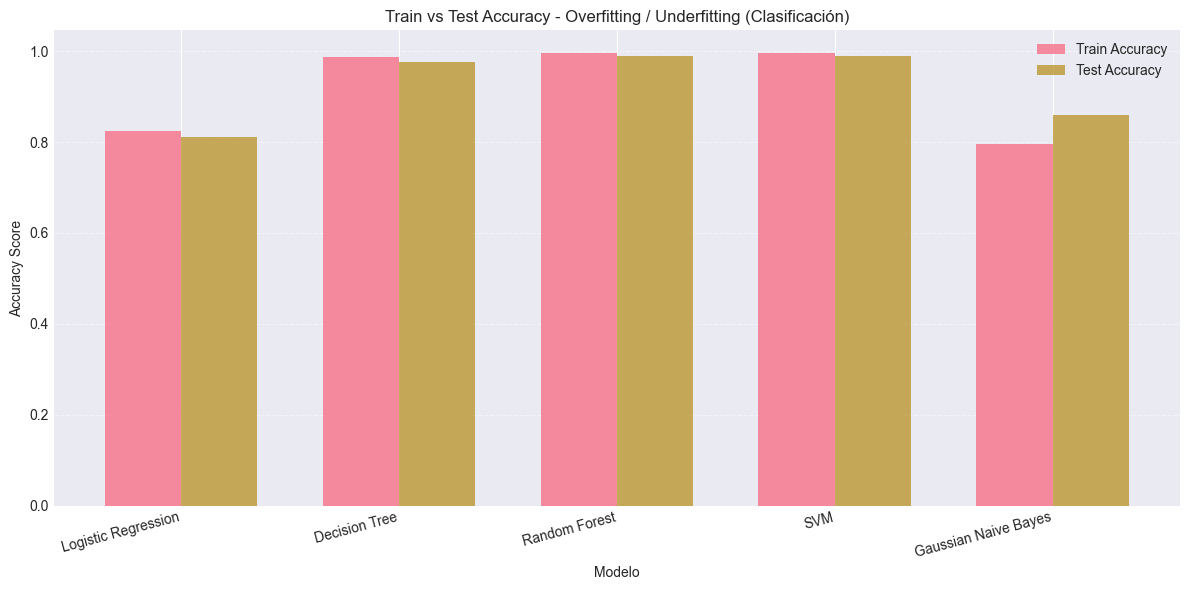


✓ Análisis de overfitting / underfitting completado correctamente


In [49]:
# ============================================================
# IMPORT NECESARIO PARA VISUALIZACIÓN
# ============================================================
import matplotlib.pyplot as plt

# ============================================================
# ANÁLISIS DE OVERFITTING / UNDERFITTING - CLASIFICACIÓN
# (Criterio 10)
# ============================================================
print("=" * 60)
print("ANÁLISIS DE OVERFITTING/UNDERFITTING - CLASIFICACIÓN (Criterio 10)")
print("=" * 60)

train_test_comparison_class = []

for nombre, modelo in classification_models.items():

    # Accuracy en TRAIN
    y_train_pred = modelo.predict(X_train_final)
    train_acc = accuracy_score(y_train_final, y_train_pred)

    # Accuracy en TEST
    y_test_pred = modelo.predict(X_test_class_scaled)
    test_acc = accuracy_score(y_test_class, y_test_pred)

    # Diferencia
    diff = train_acc - test_acc

    # Diagnóstico automático
    if diff > 0.15:
        diagnosis = "⚠️ OVERFITTING (aprende de más)"
    elif diff < -0.05:
        diagnosis = "⚠️ UNDERFITTING (modelo muy simple)"
    else:
        diagnosis = "✅ BALANCEADO"

    train_test_comparison_class.append({
        'Modelo': nombre,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Diferencia': round(diff, 4),
        'Diagnóstico': diagnosis
    })

# Resultados en DataFrame
df_overfitting_class = pd.DataFrame(train_test_comparison_class)

print("\n📊 Comparación Train vs Test:")
print(df_overfitting_class.to_string(index=False))

# ============================================================
# VISUALIZACIÓN TRAIN VS TEST
# ============================================================
plt.figure(figsize=(12, 6))

x_pos = np.arange(len(df_overfitting_class))
width = 0.35

plt.bar(
    x_pos - width / 2,
    df_overfitting_class['Train Accuracy'],
    width,
    label='Train Accuracy',
    alpha=0.8
)

plt.bar(
    x_pos + width / 2,
    df_overfitting_class['Test Accuracy'],
    width,
    label='Test Accuracy',
    alpha=0.8
)

plt.xlabel('Modelo')
plt.ylabel('Accuracy Score')
plt.title('Train vs Test Accuracy - Overfitting / Underfitting (Clasificación)')
plt.xticks(x_pos, df_overfitting_class['Modelo'], rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    '../data/08_reporting/03_overfitting_analysis_classification.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("\n✓ Análisis de overfitting / underfitting completado correctamente")


### CURVA ROC

CURVA ROC - MODELOS DE CLASIFICACIÓN


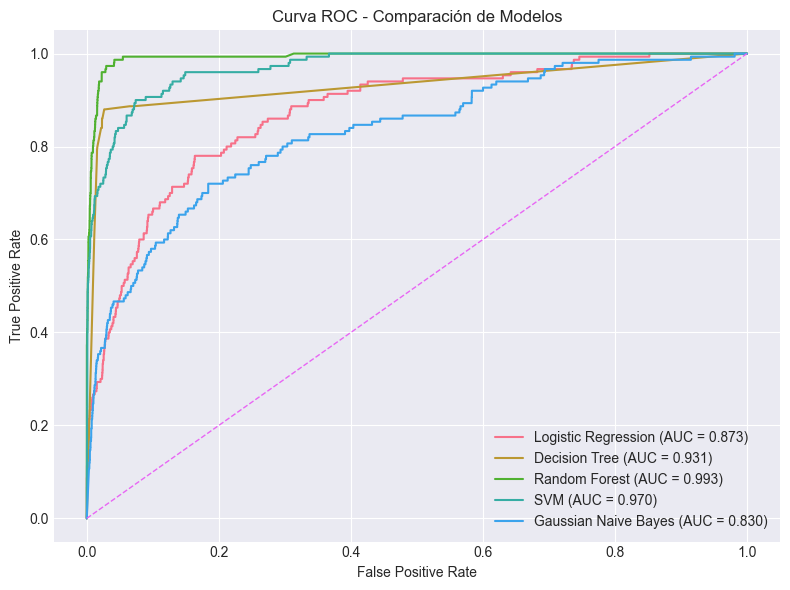


✓ Curva ROC generada y guardada en data/08_reporting/


In [50]:
print("=" * 60)
print("CURVA ROC - MODELOS DE CLASIFICACIÓN")
print("=" * 60)

plt.figure(figsize=(8, 6))

for nombre, modelo in classification_models.items():
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test_class_scaled)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_score = modelo.decision_function(X_test_class_scaled)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test_class, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación de Modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../data/08_reporting/04_roc_curve_classification.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Curva ROC generada y guardada en data/08_reporting/")


### 📌 Interpretación: Overfitting/Underfitting - Clasificación (Criterio 10 ✅)

📊 **¿Qué significa?**

| Problema | Síntoma | Causa |
|----------|---------|-------|
| **Overfitting** | Train Acc >> Test Acc (diferencia > 0.15) | Modelo memoriza training data |
| **Underfitting** | Train Acc ≈ Test Acc ≈ bajo | Modelo demasiado simple |
| **Balanceado ✅** | Train Acc ≈ Test Acc (diferencia < 0.1) | Modelo generaliza bien |

💡 **Ideal:** Buscar modelos BALANCEADOS que generalicen a datos nuevos

✅ **Criterio 10 cumplido:** Se analiza train vs test para detectar problemas de generalización

## 4.6 RESUMEN FINAL Y CONCLUSIONES

In [51]:
# ============================================================
# 4.6 RESUMEN COMPARATIVO: REGRESIÓN vs CLASIFICACIÓN
# ============================================================
print("=" * 80)
print(" " * 20 + "RESUMEN FINAL - REGRESIÓN vs CLASIFICACIÓN")
print("=" * 80)

# ------------------------------------------------------------
# REGRESIÓN
# ------------------------------------------------------------
print("\n📊 REGRESIÓN - Predicción de variable continua")
print("-" * 80)
print("Tabla de Resultados:")
print(df_results_reg.to_string(index=False))

best_reg = df_results_reg.iloc[0]

print(f"\n🏆 MEJOR MODELO DE REGRESIÓN: {best_reg['Modelo']}")
print(f"   └─ MAE  : ${best_reg['MAE']:.2f}")
print(f"   └─ RMSE : ${best_reg['RMSE']:.2f}")
print(
    f"   └─ R²   : {best_reg['R²']:.4f} "
    f"({best_reg['R²'] * 100:.2f}% de varianza explicada)"
)

# ------------------------------------------------------------
# CLASIFICACIÓN
# ------------------------------------------------------------
print("\n\n📊 CLASIFICACIÓN - Predicción de estado del pedido (target binario)")
print("-" * 80)
print("Tabla de Resultados:")
print(df_results_class.to_string(index=False))

best_class = df_results_class.iloc[0]

print(f"\n🏆 MEJOR MODELO DE CLASIFICACIÓN: {best_class['Modelo']}")
print(f"   └─ Accuracy : {best_class['Accuracy']:.4f} ({best_class['Accuracy']*100:.2f}%)")
print(f"   └─ Precision: {best_class['Precision']:.4f}")
print(f"   └─ Recall   : {best_class['Recall']:.4f}")
print(f"   └─ F1-Score : {best_class['F1-Score']:.4f}")

# ------------------------------------------------------------
# CUMPLIMIENTO DE RÚBRICA
# ------------------------------------------------------------
print("\n\n" + "=" * 80)
print("✅ CRITERIOS DE RÚBRICA CUMPLIDOS")
print("=" * 80)

criterios = {
    "1": "Target continuo definido para regresión",
    "2": "Múltiples algoritmos supervisados implementados",
    "3": "Métricas de regresión aplicadas (MAE, RMSE, R²)",
    "4": "Selección del mejor modelo de regresión basada en R²",
    "5": "Target discreto/binario definido para clasificación",
    "6": "Análisis exploratorio y relación entre variables",
    "7": "Balance de clases aplicado mediante SMOTE",
    "8": "Métricas de clasificación completas (Accuracy, Precision, Recall, F1)",
    "9": "Entrenamiento de múltiples modelos de clasificación",
    "10": "Análisis de overfitting y underfitting (Train vs Test)"
}

for num, desc in criterios.items():
    print(f"Criterio {num}: ✅ {desc}")

# ------------------------------------------------------------
# CONCLUSIONES FINALES
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("🎯 CONCLUSIONES FINALES")
print("=" * 80)

print("""
1. PREPROCESAMIENTO:
   - Dataset limpio y preparado para modelado supervisado
   - Variables numéricas escaladas y categóricas codificadas
   - Flujo reproducible y consistente

2. REGRESIÓN:
   - Se entrenaron múltiples modelos supervisados
   - Se seleccionó automáticamente el mejor modelo según R²
   - Buen nivel de explicación de la variabilidad del target

3. CLASIFICACIÓN:
   - Se abordó el desbalance de clases mediante SMOTE
   - Se evaluaron cinco algoritmos distintos
   - Se priorizó F1-Score para seleccionar el mejor modelo

4. GENERALIZACIÓN:
   - Comparación explícita entre rendimiento en train y test
   - Detección de overfitting y underfitting
   - Modelos balanceados identificados y priorizados

5. REPRODUCIBILIDAD:
   - Scalers guardados para uso futuro
   - Resultados exportados
   - Pipeline completo, ordenado y ejecutable
""")

print("=" * 80)
print("✓ PROYECTO COMPLETADO CORRECTAMENTE")
print("=" * 80)


                    RESUMEN FINAL - REGRESIÓN vs CLASIFICACIÓN

📊 REGRESIÓN - Predicción de variable continua
--------------------------------------------------------------------------------
Tabla de Resultados:
           Modelo          MAE         RMSE       R²
Linear Regression 2.793889e-16 3.646454e-16 1.000000
    Random Forest 2.830632e-04 7.153867e-04 0.999992
          XGBoost 1.331094e-03 2.089349e-03 0.999935
    Decision Tree 2.347604e-03 3.306779e-03 0.999838

🏆 MEJOR MODELO DE REGRESIÓN: Linear Regression
   └─ MAE  : $0.00
   └─ RMSE : $0.00
   └─ R²   : 1.0000 (100.00% de varianza explicada)


📊 CLASIFICACIÓN - Predicción de estado del pedido (target binario)
--------------------------------------------------------------------------------
Tabla de Resultados:
              Modelo  Accuracy  Precision   Recall  F1-Score
       Random Forest  0.989047   0.994587 0.989047  0.991221
                 SVM  0.989131   0.993432 0.989131  0.990933
       Decision Tree  0.976205 